In [2]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\_aromatic_2025_1614_CClHN.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
853,"N-(5-Chloro-2,2-dimethyl-1-phenyl-pentylidene)...",C16H24ClN,265,123529-03-3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)N=C(c1ccccc1)C(C)(C)CCCCl,CClHN
949,"3,6-Dichloro-4-[4-methylpiperazin-1-yl]pyridazine",C9H12Cl2N4,246,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CN1CCN(CC1)c2cc(Cl)nnc2Cl,CClHN
1514,"2,3,5-Trichloro-6-[1,4]diazepan-1-yl-isonicoti...",C11H11Cl3N4,304,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Clc1nc(N2CCCNCC2)c(Cl)c(C#N)c1Cl,CClHN
2169,"Carbonimidic dihydrazide, bis[(4-chlorophenyl)...",C15H13Cl2N5,333,25875-51-8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,N/C(N\N=C\c1ccc(Cl)cc1)=N\N=C\c2ccc(Cl)cc2,CClHN
2612,"3-[3,4-Dichlorophenyl]-6-[4-methyl-1-piperazin...",C13H14Cl2N6,324,72115-58-3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CN1CCN(CC1)c2nnc(nn2)c3ccc(Cl)c(Cl)c3,CClHN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180748,"Naphthalen-1,4-imine, 5,6,7,8-tetrachloro-9-(1...",C14H13Cl4N,335,60857-29-6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)(C)N1C2C=CC1c3c(Cl)c(Cl)c(Cl)c(Cl)c23,CClHN
180968,2-Chloro-2-phenylethylamine,C8H10ClN,155,4633-92-5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,NCC(Cl)c1ccccc1,CClHN
181288,Trichloromelamine,C3H3Cl3N6,228,7673-09-8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,ClNc1nc(NCl)nc(NCl)n1,CClHN
181703,"1,3,5-Triazine-2,4-diamine, 6-chloro-N,N'-di-2...",C9H12ClN5,225,15468-86-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Clc1nc(NCC=C)nc(NCC=C)n1,CClHN


In [4]:
import deepchem as dc
import selfies as sf
import pandas as pd

# Assuming ms is your DataFrame
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:
        # Add to drop list if encoding fails (chemically invalid SMILES)
        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(1614), np.int64(600)), y.shape: (np.int64(1614),), w.shape: (np.int64(1614),), task_names: [0]>

In [5]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C-1]': 2,
 '[#C]': 3,
 '[#N]': 4,
 '[/C]': 5,
 '[/N]': 6,
 '[=Branch1]': 7,
 '[=Branch2]': 8,
 '[=C]': 9,
 '[=N+1]': 10,
 '[=N-1]': 11,
 '[=N]': 12,
 '[=Ring1]': 13,
 '[=Ring2]': 14,
 '[Branch1]': 15,
 '[Branch2]': 16,
 '[C@@H1]': 17,
 '[C@H1]': 18,
 '[C]': 19,
 '[Cl]': 20,
 '[N+1]': 21,
 '[NH1]': 22,
 '[N]': 23,
 '[O]': 24,
 '[P]': 25,
 '[Ring1]': 26,
 '[Ring2]': 27,
 '[S]': 28,
 '[\\C]': 29,
 '[\\N]': 30,
 '[nop]': 31}

In [6]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [7]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 1417
📦 Validation set size: 0
📦 Test set size: 197


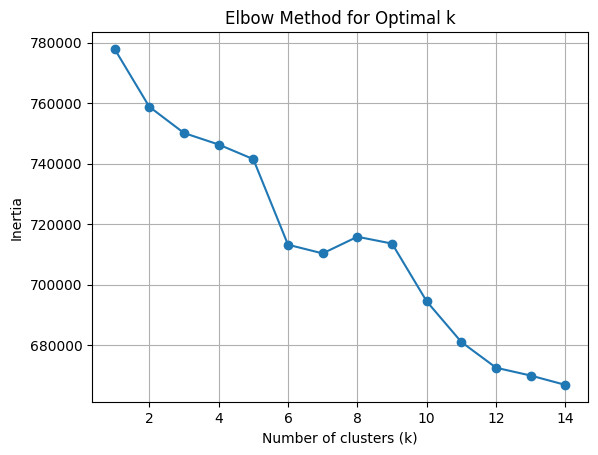

🔍 Elbow point detected at k = 6


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [ ]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=6,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=6)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splittin

In [10]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(6):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (58, 600)
Cluster 1 shape: (185, 600)
Cluster 2 shape: (49, 600)
Cluster 3 shape: (878, 600)
Cluster 4 shape: (48, 600)
Cluster 5 shape: (199, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splittin

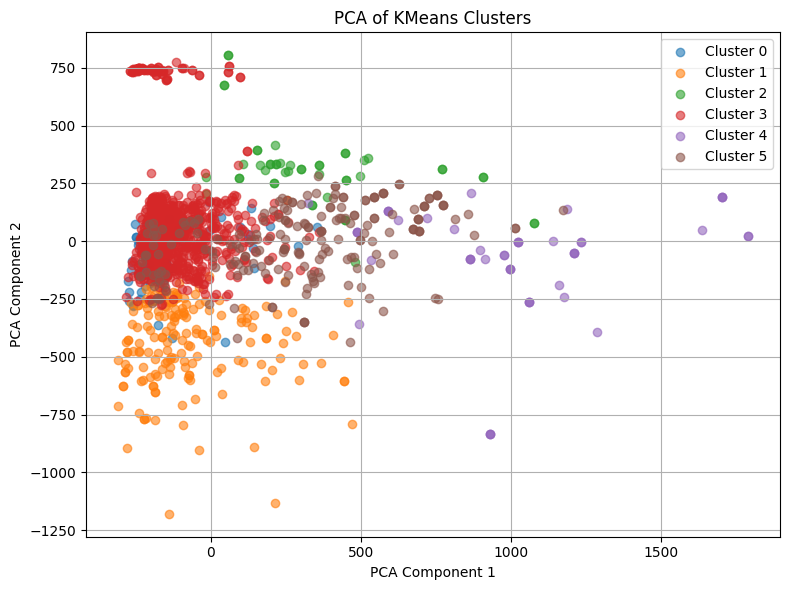

In [11]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=6)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [12]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [ ]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")


✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_in

Cluster 0: size = 11, shape = (11, 600)
Cluster 1: size = 15, shape = (15, 600)
Cluster 2: size = 8, shape = (8, 600)
Cluster 3: size = 116, shape = (116, 600)
Cluster 4: size = 10, shape = (10, 600)
Cluster 5: size = 37, shape = (37, 600)


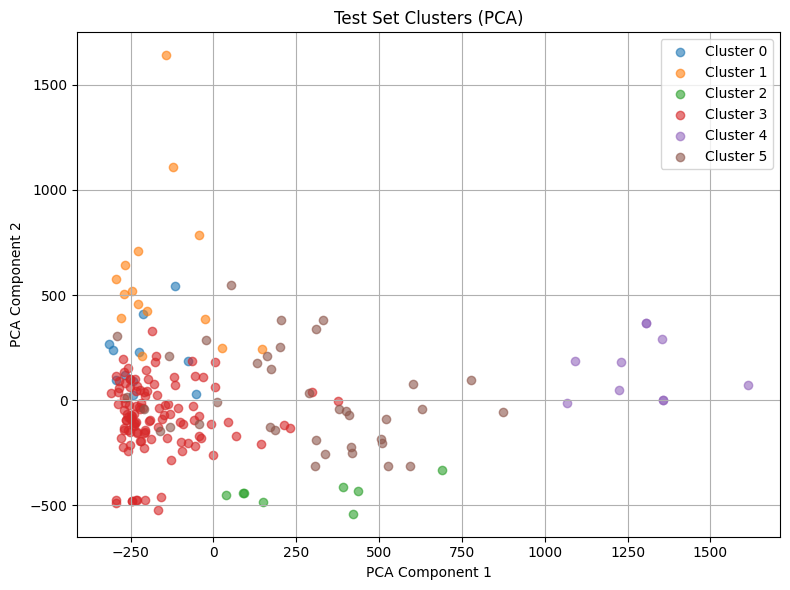

In [14]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(6):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 1.252645
Epoch 2/100 - Loss: 0.174996
Epoch 3/100 - Loss: 0.041845
Epoch 4/100 - Loss: 0.034705
Epoch 5/100 - Loss: 0.033742
Epoch 6/100 - Loss: 0.030855
Epoch 7/100 - Loss: 0.026642
Epoch 8/100 - Loss: 0.023775
Epoch 9/100 - Loss: 0.021551
Epoch 10/100 - Loss: 0.019162
Epoch 11/100 - Loss: 0.017673
Epoch 12/100 - Loss: 0.016231
Epoch 13/100 - Loss: 0.014776
Epoch 14/100 - Loss: 0.013600
Epoch 15/100 - Loss: 0.012874
Epoch 16/100 - Loss: 0.012485
Epoch 17/100 - Loss: 0.011607
Epoch 18/100 - Loss: 0.011087
Epoch 19/100 - Loss: 0.010486
Epoch 20/100 - Loss: 0.010173
Epoch 21/100 - Loss: 0.009682
Epoch 22/100 - Loss: 0.009121
Epoch 23/100 - Loss: 0.008713
Epoch 24/100 - Loss: 0.008345
Epoch 25/100 - Loss: 0.007629
Epoch 26/100 - Loss: 0.007292
Epoch 27/100 - Loss: 0.007050
Epoch 28/100 - Loss: 0.006654
Epoch 29/100 - Loss: 0.006132
Epoch 30/100 - Loss: 0.005661
Epoch 31/100 - Loss: 0.005495
Epoch 32/100 - Loss: 0.005020
Epoch 33/100 - Loss: 0.004942
Epoch 34/100 - Loss

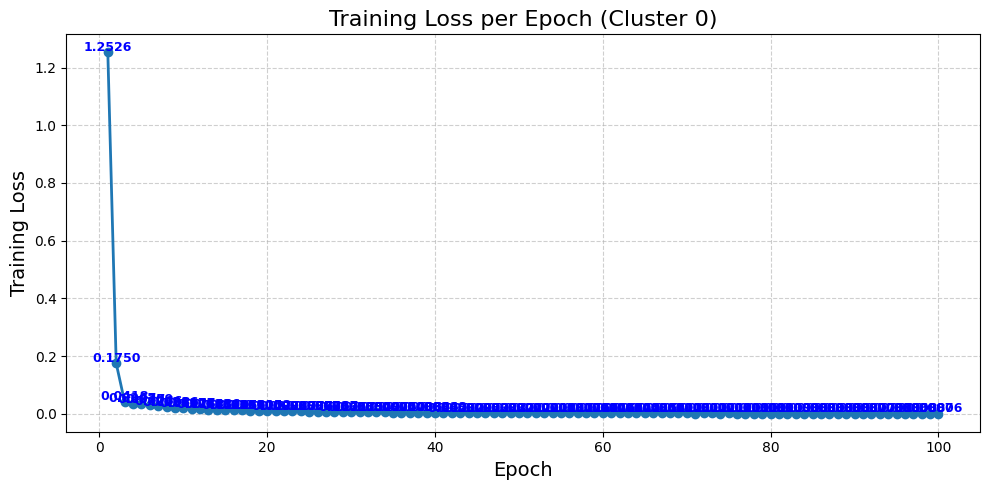

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\models_\model0000


In [15]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [16]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [17]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (11, 2144, 2)
Example prediction: [[9.9999702e-01 2.9326166e-06]
 [9.9999869e-01 1.3364280e-06]
 [9.9999857e-01 1.4137086e-06]
 ...
 [1.0000000e+00 5.5599191e-08]
 [9.9999976e-01 2.8610413e-07]
 [1.7438018e-07 9.9999988e-01]]


In [18]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [20]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [21]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: CC1=CC=C(N)C=C1 | True: CC1=CC=C(N)C(Cl)=C1 | Tanimoto: 0.481
[1] Pred: CCCC=C | True: ClC1=CC=C(NCNC2=CC=C(Cl)N=C2)C=N1 | Tanimoto: 0.004
[2] Pred: NC1=CC=C(Cl)C(N)=C1 | True: NC1=CC=C(Cl)C=C1N | Tanimoto: 0.551
[3] Pred: CC(C)C1=CC(C)CC(Cl)=N1 | True: CCNC1=CC(Cl)=NC=N1 | Tanimoto: 0.076
[4] Pred: CC1=CC=C(Cl)C(N)=C1Cl | True: CC1=CC(Cl)=CC(Cl)=C1N | Tanimoto: 0.537
[5] Pred: CCCCC=C | True: CC(C)C1=NC=CN=C1Cl | Tanimoto: 0.020
[6] Pred: CC1=CC=C(Cl)C(C)=N1 | True: CC1=CC(Cl)=CC(C)=N1 | Tanimoto: 0.540
[7] Pred: CCCCC=NCC | True: ClC1=CC=CC(=C1)N2CCCC2=NC3=CC=CC=C3C#N | Tanimoto: 0.039
[8] Pred: CC1=CC(Cl)=NC2=CC=CC=C12 | True: CC1=CC(Cl)=C2C=CC=CC2=N1 | Tanimoto: 0.453
[9] Pred: CC(=C(Cl)C#N)C1=CC=C(Cl)C=C1 | True: CC1=CC(Cl)=NC2=C(Cl)C=CC=C12 | Tanimoto: 0.172
[10] Pred: NCC1=CC(Cl)=CC(Cl)=C1 | True: NCC1=CC(Cl)=CC(Cl)=C1 | Tanimoto: 1.000

📊 Evaluation Summary:
✅ Exact SMILES match: 1/11 (9.1%)
Tanimoto >= 1.0: 1
Tanimoto >= 0.9: 1
Tanimoto >= 0.6: 1
Avg Tanimoto: 0.352


Epoch 1/100 - Loss: 1.322181
Epoch 2/100 - Loss: 0.093571
Epoch 3/100 - Loss: 0.073898
Epoch 4/100 - Loss: 0.055040
Epoch 5/100 - Loss: 0.046703
Epoch 6/100 - Loss: 0.044193
Epoch 7/100 - Loss: 0.042433
Epoch 8/100 - Loss: 0.040037
Epoch 9/100 - Loss: 0.038182
Epoch 10/100 - Loss: 0.036844
Epoch 11/100 - Loss: 0.035097
Epoch 12/100 - Loss: 0.034005
Epoch 13/100 - Loss: 0.032432
Epoch 14/100 - Loss: 0.031067
Epoch 15/100 - Loss: 0.029787
Epoch 16/100 - Loss: 0.028394
Epoch 17/100 - Loss: 0.026928
Epoch 18/100 - Loss: 0.025346
Epoch 19/100 - Loss: 0.024310
Epoch 20/100 - Loss: 0.023050
Epoch 21/100 - Loss: 0.021442
Epoch 22/100 - Loss: 0.020241
Epoch 23/100 - Loss: 0.019081
Epoch 24/100 - Loss: 0.017722
Epoch 25/100 - Loss: 0.016645
Epoch 26/100 - Loss: 0.015255
Epoch 27/100 - Loss: 0.014321
Epoch 28/100 - Loss: 0.013153
Epoch 29/100 - Loss: 0.012412
Epoch 30/100 - Loss: 0.011721
Epoch 31/100 - Loss: 0.010401
Epoch 32/100 - Loss: 0.009754
Epoch 33/100 - Loss: 0.008926
Epoch 34/100 - Loss

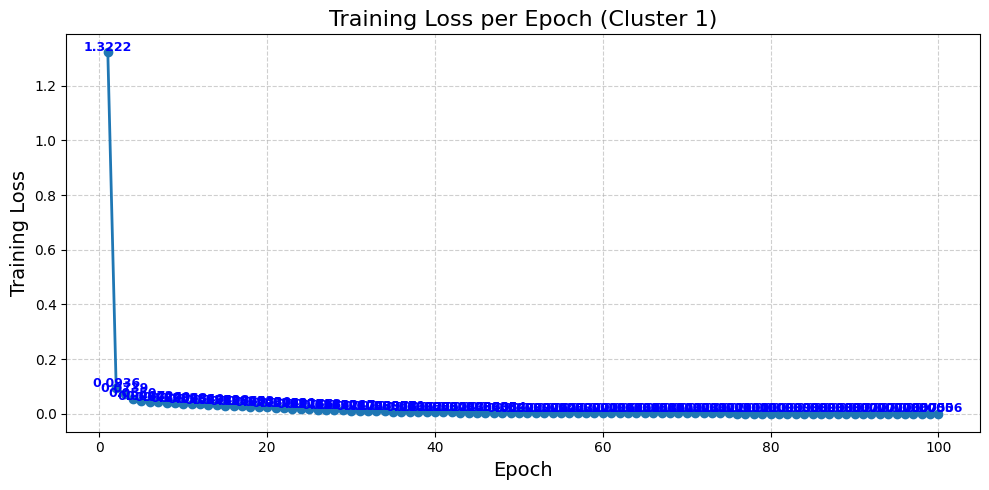

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\models_\model1111


In [22]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [23]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (15, 2144, 2)
Example prediction: [[1.0000000e+00 1.8440607e-13]
 [1.0000000e+00 8.0520795e-14]
 [1.0000000e+00 4.7693278e-13]
 ...
 [1.0000000e+00 5.2041016e-10]
 [1.0000000e+00 1.3573169e-18]
 [2.6404287e-08 1.0000000e+00]]
[0] Pred: ClC1=CC=CC(Cl)=C1CN2C=CC3=C(Cl)N=CN=C23 | True: ClC1=CC=CC(Cl)=C1CN2C=CC3=C(Cl)N=CN=C23 | Tanimoto: 1.000
[1] Pred: NN1C=NN=C1NN=CC2=CC=C(Cl)C=C2 | True: NN1C=NN=C1NN=CC2=CC=C(Cl)C=C2 | Tanimoto: 1.000
[2] Pred: ClC1=CC=C(C=C1)C(CC#N)NC2=CC=CC=C2 | True: ClC1=CC=C(C=C1)C(CC#N)NC2=CC=CC=C2 | Tanimoto: 1.000
[3] Pred: ClC=CC=C(C=NCC)CC | True: ClC1=CC=C(C=C1)C2CC(=NN2C3=CC=C(Cl)C=C3)C4=CC=C(Cl)C=C4 | Tanimoto: 0.060
[4] Pred: ClC=CC=CC | True: ClCC1=NC=NN1C2=CC=C(Cl)C=C2 | Tanimoto: 0.017
[5] Pred: ClC1=CC=C(CN2C=CC=C3C=CN=C23)C=C1 | True: ClC1=CC=C(CN2C=CC3=CC=CN=C23)C=C1 | Tanimoto: 0.455
[6] Pred: ClC1=CC=C(C=C1)C=NN2C=C(N=N2)C3=CC=CC=C3 | True: CC=1N=NN(N=CC2=CC=C(Cl)C=C2)C=1C | Tanimoto: 0.462
[7] Pred: ClC=C=NCN(C)C=CC1=CC=CC=C1C=

Epoch 1/100 - Loss: 0.957582
Epoch 2/100 - Loss: 0.156481
Epoch 3/100 - Loss: 0.053482
Epoch 4/100 - Loss: 0.046141
Epoch 5/100 - Loss: 0.040362
Epoch 6/100 - Loss: 0.034784
Epoch 7/100 - Loss: 0.030628
Epoch 8/100 - Loss: 0.026185
Epoch 9/100 - Loss: 0.023653
Epoch 10/100 - Loss: 0.022115
Epoch 11/100 - Loss: 0.020938
Epoch 12/100 - Loss: 0.019545
Epoch 13/100 - Loss: 0.018240
Epoch 14/100 - Loss: 0.016897
Epoch 15/100 - Loss: 0.015639
Epoch 16/100 - Loss: 0.014783
Epoch 17/100 - Loss: 0.014050
Epoch 18/100 - Loss: 0.012939
Epoch 19/100 - Loss: 0.012145
Epoch 20/100 - Loss: 0.011572
Epoch 21/100 - Loss: 0.010607
Epoch 22/100 - Loss: 0.010028
Epoch 23/100 - Loss: 0.009796
Epoch 24/100 - Loss: 0.009434
Epoch 25/100 - Loss: 0.008562
Epoch 26/100 - Loss: 0.008168
Epoch 27/100 - Loss: 0.007860
Epoch 28/100 - Loss: 0.007389
Epoch 29/100 - Loss: 0.006933
Epoch 30/100 - Loss: 0.006523
Epoch 31/100 - Loss: 0.006391
Epoch 32/100 - Loss: 0.006048
Epoch 33/100 - Loss: 0.005467
Epoch 34/100 - Loss

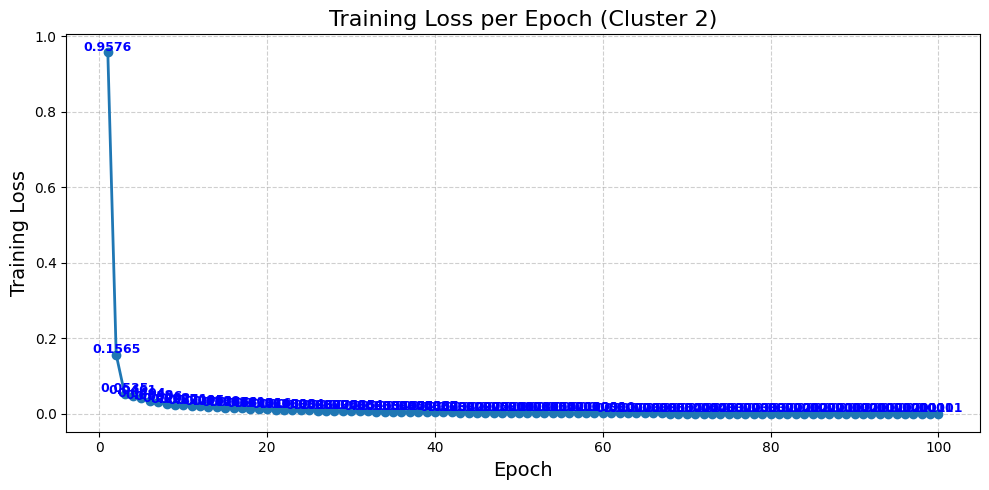

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\models_\model2222


In [24]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [25]:
# === Load cluster 2 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 2
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_2
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])

evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (8, 2144, 2)
Example prediction: [[1.00000000e+00 9.63705780e-18]
 [1.00000000e+00 3.49860259e-18]
 [1.00000000e+00 2.43666388e-13]
 ...
 [1.00000000e+00 1.07089766e-14]
 [1.00000000e+00 2.49194261e-16]
 [4.04264897e-15 1.00000000e+00]]
[0] Pred: ClC1=NC(NCCN2CCCC2)=C3C=CC=CC3=N1 | True: ClC1=NC(NCCN2CCCC2)=C3C=CC=CC3=N1 | Tanimoto: 1.000
[1] Pred: CN1CCCC1CCNC2=NC=CC(=N2)C(Cl)(Cl)Cl | True: CN1CCCC1CCNC2=NC=CC(=N2)C(Cl)(Cl)Cl | Tanimoto: 1.000
[2] Pred: CN1CCCC1CCNC2=NC(=CC(=N2)C(Cl)(Cl)Cl)C3=CC=C(Cl)C=C3 | True: CN1CCCC1CCNC2=NC(=CC(=N2)C(Cl)(Cl)Cl)C3=CC=C(Cl)C=C3 | Tanimoto: 1.000
[3] Pred: ClC(Cl)(Cl)C1=NC(NCCCCCN2CCCC2)=NC(=N1)C(Cl)(Cl)Cl | True: ClC(Cl)(Cl)C1=NC(NCCCCCN2CCCC2)=NC(=N1)C(Cl)(Cl)Cl | Tanimoto: 1.000
[4] Pred: CN1CCCC1CCNC2=NC(=CC(=N2)C(Cl)(Cl)Cl)C(Cl)Cl | True: CN1CCCC1CCNC2=NC(=CC(=N2)C(Cl)(Cl)Cl)C(Cl)Cl | Tanimoto: 1.000
[5] Pred: ClC(Cl)(Cl)C1=NC(NCCCCN2CCCC2)=NC(=N1)C(Cl)(Cl)Cl | True: ClC(Cl)(Cl)C1=NC(NCCCCN2CCCC2)=NC(=N1)C(Cl)(Cl)Cl | Tanim

Epoch 1/100 - Loss: 0.335816
Epoch 2/100 - Loss: 0.053012
Epoch 3/100 - Loss: 0.047218
Epoch 4/100 - Loss: 0.043165
Epoch 5/100 - Loss: 0.040311
Epoch 6/100 - Loss: 0.037991
Epoch 7/100 - Loss: 0.036144
Epoch 8/100 - Loss: 0.034200
Epoch 9/100 - Loss: 0.032453
Epoch 10/100 - Loss: 0.031115
Epoch 11/100 - Loss: 0.029504
Epoch 12/100 - Loss: 0.027398
Epoch 13/100 - Loss: 0.026379
Epoch 14/100 - Loss: 0.024888
Epoch 15/100 - Loss: 0.023631
Epoch 16/100 - Loss: 0.022051
Epoch 17/100 - Loss: 0.020807
Epoch 18/100 - Loss: 0.019651
Epoch 19/100 - Loss: 0.018175
Epoch 20/100 - Loss: 0.017514
Epoch 21/100 - Loss: 0.016434
Epoch 22/100 - Loss: 0.015439
Epoch 23/100 - Loss: 0.014926
Epoch 24/100 - Loss: 0.013704
Epoch 25/100 - Loss: 0.012818
Epoch 26/100 - Loss: 0.012209
Epoch 27/100 - Loss: 0.011268
Epoch 28/100 - Loss: 0.010602
Epoch 29/100 - Loss: 0.010314
Epoch 30/100 - Loss: 0.009714
Epoch 31/100 - Loss: 0.009388
Epoch 32/100 - Loss: 0.008833
Epoch 33/100 - Loss: 0.008400
Epoch 34/100 - Loss

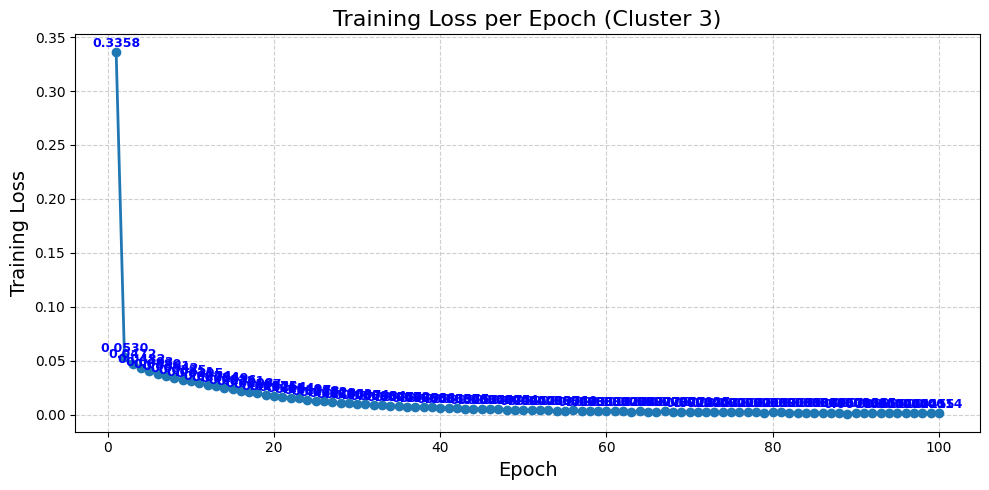

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\models_\model3333


In [27]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 3 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_3.pkl", "rb") as f:
    X_cluster3 = pickle.load(f)

cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_3_indices.npy")
y_cluster3 = train_dataset.y[cluster_3_indices]

if len(y_cluster3.shape) == 1:
    y_cluster3 = y_cluster3.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_3 = dc.data.NumpyDataset(X=np.array(X_cluster3), y=np.array(y_cluster3))

# === Model config
n_tasks = train_dataset_3.y.shape[1]
n_features = train_dataset_3.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_3 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\models_\model3333"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_3.fit(train_dataset_3, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 3)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_3.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [28]:
# === Load cluster 3 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3.pkl", "rb") as f:
    X_test_cluster3 = pickle.load(f)

# === Load corresponding indices
test_cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster3 = test_dataset.y[test_cluster_3_indices]

if len(y_test_cluster3.shape) == 1:
    y_test_cluster3 = y_test_cluster3.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 3
test_dataset_3 = dc.data.NumpyDataset(X=np.array(X_test_cluster3), y=np.array(y_test_cluster3))

# === Predict using the trained model_3
predictions_3 = model_3.predict(test_dataset_3)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_3.shape)
print("Example prediction:", predictions_3[0])

evaluate_flat_predictions(predictions_3, test_dataset_3, itos, sf, cutoff=0.5)


✅ Prediction shape: (116, 2144, 2)
Example prediction: [[1.0000000e+00 1.4511058e-15]
 [1.0000000e+00 7.1130134e-14]
 [1.0000000e+00 8.8224157e-15]
 ...
 [1.0000000e+00 1.5829173e-13]
 [1.0000000e+00 1.4791120e-14]
 [2.6617528e-15 1.0000000e+00]]
[0] Pred: NCC(Cl)C1=CC=CC=C1 | True: NCC(Cl)C1=CC=CC=C1 | Tanimoto: 1.000
[1] Pred: CCNC1(C)NC=CC1(C)CC=CCC | True: CNC1=CC=C(N=N1)C2=CC=C(Cl)C(Cl)=C2 | Tanimoto: 0.118
[2] Pred: CC(CNC1CC2N)C=CC=C3C2=NCN31 | True: CC(CN(C)C)NC1=NC(=NC(=N1)C(Cl)(Cl)Cl)C2=CC(Cl)=CC(Cl)=C2 | Tanimoto: 0.229
[3] Pred: CNC(C)CC=C=C | True: CC1C=CC2=CC=C(Cl)C=C2C1(C)CCN(C)C | Tanimoto: 0.057
[4] Pred: CCN(CC)CCN1C=2CC3=CC=CC=C3CC=2C4=CN=C5C=C(Cl)C=CC5=C14 | True: CCN(CC)CCN1C=2CC3=CC=CC=C3CC=2C4=CN=C5C=C(Cl)C=CC5=C14 | Tanimoto: 1.000
[5] Pred: CCN(CC)CCCC(C)N1C=NC2=CC=CC(Cl)=C12 | True: CCN(CC)CCCC(C)N1C=NC2=CC=CC(Cl)=C12 | Tanimoto: 1.000
[6] Pred: CCN(CC)CCCCC1NC=C(Cl)C(C)=NC1(C)Cl | True: CCN(CC)CCCCCNC1=C(Cl)C(C)=NC(C)=C1Cl | Tanimoto: 0.188
[7] Pred: CCN(CC)C

Epoch 1/100 - Loss: 1.457000
Epoch 2/100 - Loss: 0.177629
Epoch 3/100 - Loss: 0.056685
Epoch 4/100 - Loss: 0.045167
Epoch 5/100 - Loss: 0.038023
Epoch 6/100 - Loss: 0.030712
Epoch 7/100 - Loss: 0.025041
Epoch 8/100 - Loss: 0.021359
Epoch 9/100 - Loss: 0.018951
Epoch 10/100 - Loss: 0.016978
Epoch 11/100 - Loss: 0.015045
Epoch 12/100 - Loss: 0.013544
Epoch 13/100 - Loss: 0.011821
Epoch 14/100 - Loss: 0.010288
Epoch 15/100 - Loss: 0.009204
Epoch 16/100 - Loss: 0.007999
Epoch 17/100 - Loss: 0.007145
Epoch 18/100 - Loss: 0.006156
Epoch 19/100 - Loss: 0.005188
Epoch 20/100 - Loss: 0.004466
Epoch 21/100 - Loss: 0.004038
Epoch 22/100 - Loss: 0.003253
Epoch 23/100 - Loss: 0.002707
Epoch 24/100 - Loss: 0.002306
Epoch 25/100 - Loss: 0.002015
Epoch 26/100 - Loss: 0.001906
Epoch 27/100 - Loss: 0.001621
Epoch 28/100 - Loss: 0.001258
Epoch 29/100 - Loss: 0.001099
Epoch 30/100 - Loss: 0.001025
Epoch 31/100 - Loss: 0.000810
Epoch 32/100 - Loss: 0.000739
Epoch 33/100 - Loss: 0.000704
Epoch 34/100 - Loss

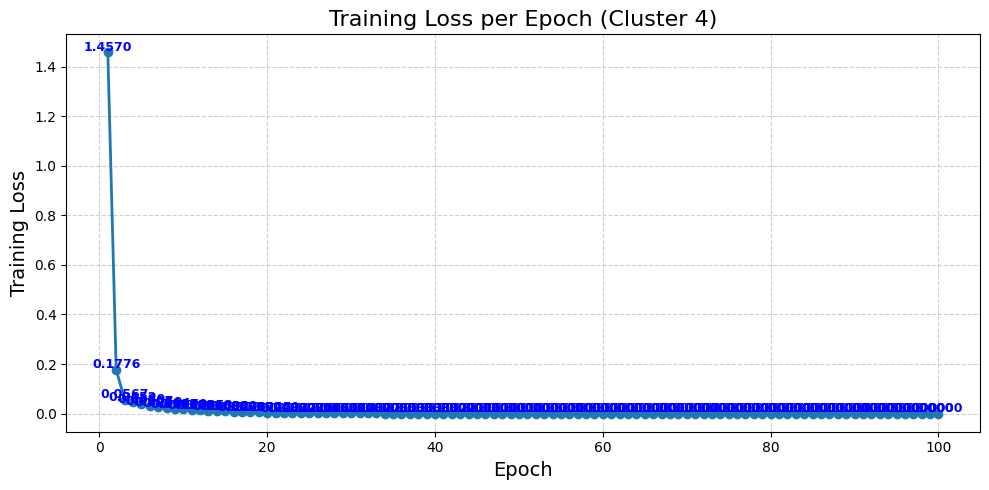

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\models_\model4444


In [29]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 4 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_4.pkl", "rb") as f:
    X_cluster4 = pickle.load(f)

cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_4_indices.npy")
y_cluster4 = train_dataset.y[cluster_4_indices]

if len(y_cluster4.shape) == 1:
    y_cluster4 = y_cluster4.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_4 = dc.data.NumpyDataset(X=np.array(X_cluster4), y=np.array(y_cluster4))

# === Model config
n_tasks = train_dataset_4.y.shape[1]
n_features = train_dataset_4.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_4 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\models_\model4444"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_4.fit(train_dataset_4, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 4)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_4.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [30]:
# === Load cluster 4 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4.pkl", "rb") as f:
    X_test_cluster4 = pickle.load(f)

# === Load corresponding indices
test_cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster4 = test_dataset.y[test_cluster_4_indices]

if len(y_test_cluster4.shape) == 1:
    y_test_cluster4 = y_test_cluster4.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 4
test_dataset_4 = dc.data.NumpyDataset(X=np.array(X_test_cluster4), y=np.array(y_test_cluster4))

# === Predict using the trained model_4
predictions_4 = model_4.predict(test_dataset_4)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_4.shape)
print("Example prediction:", predictions_4[0])

evaluate_flat_predictions(predictions_4, test_dataset_4, itos, sf, cutoff=0.5)


✅ Prediction shape: (10, 2144, 2)
Example prediction: [[1.0000000e+00 5.8948324e-12]
 [1.0000000e+00 4.9978121e-13]
 [1.0000000e+00 1.4479913e-13]
 ...
 [1.0000000e+00 1.8112229e-14]
 [1.0000000e+00 5.8061509e-13]
 [1.9412608e-15 1.0000000e+00]]
[0] Pred: ClC1=CC=C(C=C1)N2N=NN=C2C=CN3CCCCC3 | True: ClC1=CC=C(C=C1)N2N=NN=C2C=CN3CCCCC3 | Tanimoto: 1.000
[1] Pred: CC(C)(C)NC1=NC(Cl)=NC(=N1)N2CCCCC2 | True: CC(C)(C)NC1=NC(Cl)=NC(=N1)N2CCCCC2 | Tanimoto: 1.000
[2] Pred: CC(C)(N)C=NCCl | True: CCNC1=NC(Cl)=NC(NC(C)(C)C#N)=N1 | Tanimoto: 0.077
[3] Pred: C1NC=NC(Cl)=NCC(C)=N1 | True: CC(C)NC(CCCCCl)C1=CC=CC=C1 | Tanimoto: 0.087
[4] Pred: CC(C)(C)NC=NC(Cl)=NC(NC1CCCCC1)C#N | True: ClC1=NC(NC2CCCCCC2)=NC(NC3CCCCCC3)=N1 | Tanimoto: 0.127
[5] Pred: CCN1CCC(CC1)CNC2=CC(C)=NC(N=C(N)NC3=CC=C(Cl)C(Cl)=C3)=N2 | True: CCN1CCC(CC1)CNC2=CC(C)=NC(N=C(N)NC3=CC=C(Cl)C(Cl)=C3)=N2 | Tanimoto: 1.000
[6] Pred: CC(C)(C)NC1=NC(Cl)=NC(NC2CCCCC2)=N1 | True: CC(C)(C)NC1=NC(Cl)=NC(NC2CCCCC2)=N1 | Tanimoto: 1.000
[7] P

Epoch 1/100 - Loss: 1.323552
Epoch 2/100 - Loss: 0.101080
Epoch 3/100 - Loss: 0.082177
Epoch 4/100 - Loss: 0.064622
Epoch 5/100 - Loss: 0.057644
Epoch 6/100 - Loss: 0.053814
Epoch 7/100 - Loss: 0.051747
Epoch 8/100 - Loss: 0.049883
Epoch 9/100 - Loss: 0.047795
Epoch 10/100 - Loss: 0.046044
Epoch 11/100 - Loss: 0.044155
Epoch 12/100 - Loss: 0.042448
Epoch 13/100 - Loss: 0.040471
Epoch 14/100 - Loss: 0.038862
Epoch 15/100 - Loss: 0.036860
Epoch 16/100 - Loss: 0.035246
Epoch 17/100 - Loss: 0.033512
Epoch 18/100 - Loss: 0.031218
Epoch 19/100 - Loss: 0.029526
Epoch 20/100 - Loss: 0.027612
Epoch 21/100 - Loss: 0.025660
Epoch 22/100 - Loss: 0.024293
Epoch 23/100 - Loss: 0.022448
Epoch 24/100 - Loss: 0.020805
Epoch 25/100 - Loss: 0.019534
Epoch 26/100 - Loss: 0.018099
Epoch 27/100 - Loss: 0.016880
Epoch 28/100 - Loss: 0.015475
Epoch 29/100 - Loss: 0.014426
Epoch 30/100 - Loss: 0.013857
Epoch 31/100 - Loss: 0.012446
Epoch 32/100 - Loss: 0.011823
Epoch 33/100 - Loss: 0.010874
Epoch 34/100 - Loss

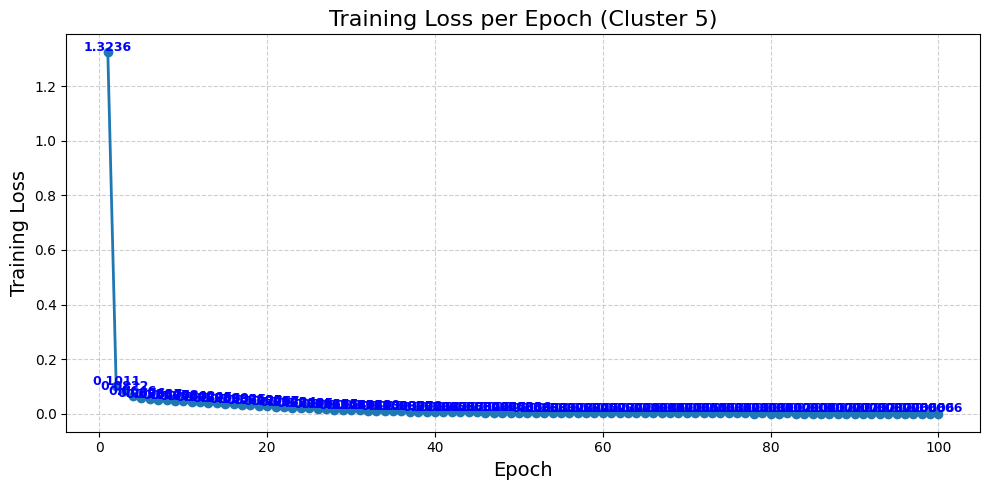

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\models_\model5555


In [31]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 5 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_5.pkl", "rb") as f:
    X_cluster5 = pickle.load(f)

cluster_5_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  seed 123\clustering_from_trainset\cluster_5_indices.npy")
y_cluster5 = train_dataset.y[cluster_5_indices]

if len(y_cluster5.shape) == 1:
    y_cluster5 = y_cluster5.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_5 = dc.data.NumpyDataset(X=np.array(X_cluster5), y=np.array(y_cluster5))

# === Model config
n_tasks = train_dataset_5.y.shape[1]
n_features = train_dataset_5.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_5 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with seed 123\models_\model5555"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_5.fit(train_dataset_5, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 5)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_5.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [32]:
# === Load cluster 5 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_5.pkl", "rb") as f:
    X_test_cluster5 = pickle.load(f)

# === Load corresponding indices
test_cluster_5_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1614_CClHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_5_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster5 = test_dataset.y[test_cluster_5_indices]

if len(y_test_cluster5.shape) == 1:
    y_test_cluster5 = y_test_cluster5.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 5
test_dataset_5 = dc.data.NumpyDataset(X=np.array(X_test_cluster5), y=np.array(y_test_cluster5))

# === Predict using the trained model_5
predictions_5 = model_5.predict(test_dataset_5)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_5.shape)
print("Example prediction:", predictions_5[0])

evaluate_flat_predictions(predictions_5, test_dataset_5, itos, sf, cutoff=0.5)


✅ Prediction shape: (37, 2144, 2)
Example prediction: [[1.00000000e+00 1.02564922e-15]
 [1.00000000e+00 5.24994363e-17]
 [1.00000000e+00 3.46609460e-19]
 ...
 [1.00000000e+00 2.87229744e-20]
 [1.00000000e+00 1.25867784e-20]
 [2.92445869e-21 1.00000000e+00]]
[0] Pred: CC(C)N=C(C1=CC=CC=C1)C(C)(C)CCCCl | True: CC(C)N=C(C1=CC=CC=C1)C(C)(C)CCCCl | Tanimoto: 1.000
[1] Pred: NC1=NC(N)=C2CN(CC3=CC(Cl)=CC(Cl)=C3)CC2=N1 | True: NC1=NC(N)=C2CN(CC3=CC(Cl)=CC(Cl)=C3)CC2=N1 | Tanimoto: 1.000
[2] Pred: ClC1=CC=C(C=NC23CN4CN(CN(C4)C2)C3)C(Cl)=C1 | True: ClC1=CC=C(C=NC23CN4CN(CN(C4)C2)C3)C(Cl)=C1 | Tanimoto: 1.000
[3] Pred: CN1CCC(CC1)CC2=CC=C(Cl)C=C2 | True: CN1CCC(CC1)CC2=CC=C(Cl)C=C2 | Tanimoto: 1.000
[4] Pred: CN(C)CC#CC1=CC=CC(Cl)=C1 | True: CN(C)CC#CC1=CC=CC(Cl)=C1 | Tanimoto: 1.000
[5] Pred: C1N(C)C1(C)CCC(C)C | True: CCN(CC)C1=NC=C(C)C(Cl)=N1 | Tanimoto: 0.063
[6] Pred: C1CCCC=CC=C(Cl)C1C=CCCC=CC | True: CN(C)C(C1=CC=CC=C1)C2=CC(Cl)=CC=C2N(C)C | Tanimoto: 0.071
[7] Pred: CC(C)CCCNC=CC#CNC | Tr